# Starter Notebook with Report Visuals  
## Applied AI Project — Single-Language XLSum Summarization with mBART-50

## 1. Install dependencies

In [ ]:
!pip -q uninstall -y datasets
!pip -q install "datasets==3.6.0" "transformers>=4.46,<5" evaluate sentencepiece accelerate rouge_score pandas


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
import evaluate

from transformers import (
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)

## 3. Configuration

In [ ]:
# ========= MODEL CONFIG =========
MODEL_NAME = "facebook/mbart-large-50-many-to-many-mmt"

# valid XLSum options used in this project:
# "english", "spanish", "french", "russian", "portuguese"
LANGUAGE = "russian"

MBART_LANG_CODES = {
    "english": "en_XX",
    "spanish": "es_XX",
    "french": "fr_XX",
    "russian": "ru_RU",
    "portuguese": "pt_XX",
}

MAX_INPUT_LEN = 512
MAX_TARGET_LEN = 64

TRAIN_SAMPLES = 2000
VAL_SAMPLES = 300
TEST_SAMPLES = 300

# conservative settings for A100
LEARNING_RATE = 5e-5
PER_DEVICE_TRAIN_BATCH_SIZE = 1
PER_DEVICE_EVAL_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 8

LANG_SHORT = LANGUAGE[:2]
OUTPUT_DIR = f"./mbart50_xlsum_{LANG_SHORT}_singlelang_starter_visuals"
PLOTS_DIR = os.path.join(OUTPUT_DIR, "report_plots")
TABLES_DIR = os.path.join(OUTPUT_DIR, "report_tables")

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

print("HF model:", MODEL_NAME)
print("Language:", LANGUAGE)
print("mBART language code:", MBART_LANG_CODES[LANGUAGE])


HF model: facebook/mbart-large-50-many-to-many-mmt
Language: russian
mBART language code: ru_RU


## 4. Load XLSum dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset("csebuetnlp/xlsum", LANGUAGE)
dataset


data/russian_XLSum_v2.0.tar.bz2:   0%|          | 0.00/105M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 62243
    })
    test: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 7780
    })
    validation: Dataset({
        features: ['id', 'url', 'title', 'summary', 'text'],
        num_rows: 7780
    })
})

## 5. Inspect an example

In [ ]:
sample = dataset["train"][0]
print("Keys:", sample.keys())
print("\nArticle preview:\n", sample["text"][:1000])
print("\nSummary preview:\n", sample["summary"])

Keys: dict_keys(['id', 'url', 'title', 'summary', 'text'])

Article preview:
 В прошлом году президент Чон Ду Хван едва избежал убийства северо-корейскими агентами, взорвавшими бомбу, от которой погибли несколько правительственных министров. О визите г-на Ли не было объявлено публично. Ожидается, что в Бирме, которая стала на путь реформ, лидеры стран обсудят торгово-экономическое развитие. По словам аналитиков, среди тем переговоров может быть и Северная Корея, которая, по данным СМИ, продолжает военное сотрудничество с Бирмой.

Summary preview:
 Президент Южной Кореи Ли Мун-бак прибыл в Бирму, начав первый визит южнокорейского лидера в эту страну с 1983 года.


## 6. Create small subsets for a Colab starter run

In [ ]:
train_ds = dataset["train"].shuffle(seed=42).select(range(min(TRAIN_SAMPLES, len(dataset["train"]))))
val_ds = dataset["validation"].shuffle(seed=42).select(range(min(VAL_SAMPLES, len(dataset["validation"]))))
test_ds = dataset["test"].shuffle(seed=42).select(range(min(TEST_SAMPLES, len(dataset["test"]))))

print(train_ds)
print(val_ds)
print(test_ds)

Dataset({
    features: ['id', 'url', 'title', 'summary', 'text'],
    num_rows: 2000
})
Dataset({
    features: ['id', 'url', 'title', 'summary', 'text'],
    num_rows: 300
})
Dataset({
    features: ['id', 'url', 'title', 'summary', 'text'],
    num_rows: 300
})


## 7. Dataset summary table for report

In [ ]:
dataset_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Samples Used": [len(train_ds), len(val_ds), len(test_ds)]
})
dataset_summary

,Split,Samples Used
0,Train,2000
1,Validation,300
2,Test,300


In [ ]:
dataset_summary.to_csv(os.path.join(TABLES_DIR, "dataset_summary.csv"), index=False)
print("Saved:", os.path.join(TABLES_DIR, "dataset_summary.csv"))

Saved: ./mbart50_xlsum_ru_singlelang_starter_visuals/report_tables/dataset_summary.csv


## 8. Visualize source and target length distributions

In [ ]:
def get_lengths(ds, text_col="text", summary_col="summary", max_rows=500):
    rows = min(max_rows, len(ds))
    article_lens = [len(ds[i][text_col].split()) for i in range(rows)]
    summary_lens = [len(ds[i][summary_col].split()) for i in range(rows)]
    return article_lens, summary_lens

article_lens, summary_lens = get_lengths(train_ds)

print("Average article length:", round(np.mean(article_lens), 2))
print("Average summary length:", round(np.mean(summary_lens), 2))

Average article length: 581.63
Average summary length: 25.61


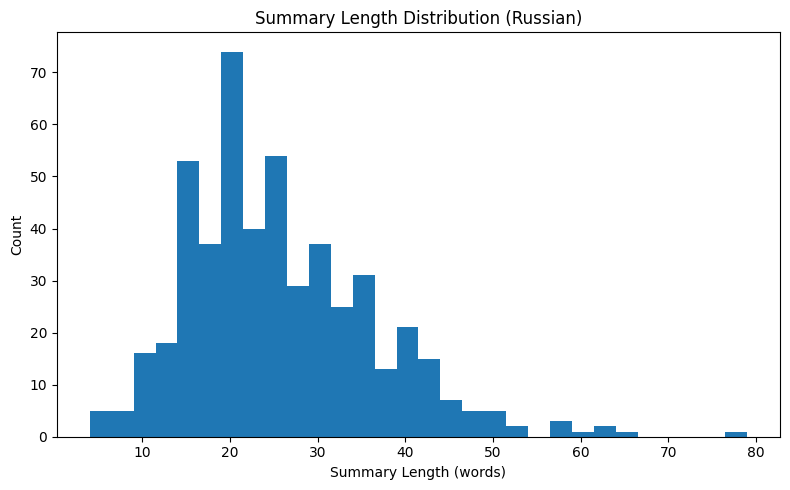

Saved: ./mbart50_xlsum_ru_singlelang_starter_visuals/report_plots/summary_length_hist_ru.png


In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(summary_lens, bins=30)
plt.xlabel("Summary Length (words)")
plt.ylabel("Count")
plt.title(f"Summary Length Distribution ({LANGUAGE.title()})")
plt.tight_layout()
plot_path = os.path.join(PLOTS_DIR, f"summary_length_hist_{LANG_SHORT}.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

## 9. Load tokenizer and model

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

if hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable()

tokenizer.src_lang = MBART_LANG_CODES[LANGUAGE]
tokenizer.tgt_lang = MBART_LANG_CODES[LANGUAGE]
model.config.forced_bos_token_id = tokenizer.lang_code_to_id[MBART_LANG_CODES[LANGUAGE]]

print("Loaded tokenizer and model for:", MODEL_NAME)


Loaded tokenizer and model for: facebook/mbart-large-50-many-to-many-mmt


## 10. Preprocessing

In [ ]:
def preprocess_function(batch):
    texts = batch["text"]
    summaries = batch["summary"]

    tokenizer.src_lang = MBART_LANG_CODES[LANGUAGE]
    model_inputs = tokenizer(
        texts,
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding="max_length"
    )

    tokenizer.tgt_lang = MBART_LANG_CODES[LANGUAGE]
    labels = tokenizer(
        text_target=summaries,
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding="max_length"
    )

    cleaned_labels = []
    for seq in labels["input_ids"]:
        cleaned_labels.append([token if token != tokenizer.pad_token_id else -100 for token in seq])

    model_inputs["labels"] = cleaned_labels
    return model_inputs


## 11. Tokenize datasets

In [ ]:
tokenized_train = train_ds.map(preprocess_function, batched=True, remove_columns=train_ds.column_names)
tokenized_val = val_ds.map(preprocess_function, batched=True, remove_columns=val_ds.column_names)
tokenized_test = test_ds.map(preprocess_function, batched=True, remove_columns=test_ds.column_names)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

## 12. ROUGE metric

In [ ]:
rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.where(
        (predictions < 0) | (predictions >= tokenizer.vocab_size),
        tokenizer.pad_token_id,
        predictions
    )

    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]

    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=False
    )

    return {
        "rouge1": round(result["rouge1"], 4),
        "rouge2": round(result["rouge2"], 4),
        "rougeL": round(result["rougeL"], 4),
        "rougeLsum": round(result["rougeLsum"], 4),
    }

## 13. Data collator

In [ ]:
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

## 14. Training arguments

In [ ]:
supports_bf16 = (
    torch.cuda.is_available()
    and torch.cuda.get_device_capability(0)[0] >= 8
)

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=1,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,
    bf16=supports_bf16,
    fp16=torch.cuda.is_available() and not supports_bf16,
    logging_steps=25,
    report_to="none",
    logging_dir=os.path.join(OUTPUT_DIR, "logs"),
)


## 15. Trainer

In [ ]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


/tmp/ipykernel_552/4048247955.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


## 16. Train

In [ ]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,2.603900,2.415152,0.063100,0.020000,0.062800,0.062800


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200, 'early_stopping': True, 'num_beams': 5, 'forced_bos_token_id': 250021}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


TrainOutput(global_step=250, training_loss=2.690514633178711, metrics={'train_runtime': 514.4824, 'train_samples_per_second': 3.887, 'train_steps_per_second': 0.486, 'total_flos': 2167129767936000.0, 'train_loss': 2.690514633178711, 'epoch': 1.0})

## 17. Evaluate on test set

In [ ]:
test_results = trainer.evaluate(eval_dataset=tokenized_test, metric_key_prefix="test")
test_results

{'test_loss': 2.379005193710327,
 'test_rouge1': 0.0646,
 'test_rouge2': 0.019,
 'test_rougeL': 0.0652,
 'test_rougeLsum': 0.0655,
 'test_runtime': 223.1437,
 'test_samples_per_second': 1.344,
 'test_steps_per_second': 1.344,
 'epoch': 1.0}

## 18. Save a clean results table for the report

In [ ]:
results_df = pd.DataFrame([{
    "Model": "mBART-50",
    "Language": LANGUAGE,
    "ROUGE-1": test_results.get("test_rouge1"),
    "ROUGE-2": test_results.get("test_rouge2"),
    "ROUGE-L": test_results.get("test_rougeL"),
    "ROUGE-Lsum": test_results.get("test_rougeLsum"),
}])

results_df


,Model,Language,ROUGE-1,ROUGE-2,ROUGE-L,ROUGE-Lsum
0,mBART-50,russian,0.0646,0.019,0.0652,0.0655


In [ ]:
results_csv = os.path.join(TABLES_DIR, f"rouge_results_{LANG_SHORT}.csv")
results_df.to_csv(results_csv, index=False)
print("Saved:", results_csv)

Saved: ./mbart50_xlsum_ru_singlelang_starter_visuals/report_tables/rouge_results_ru.csv


## 19. ROUGE bar chart for the report

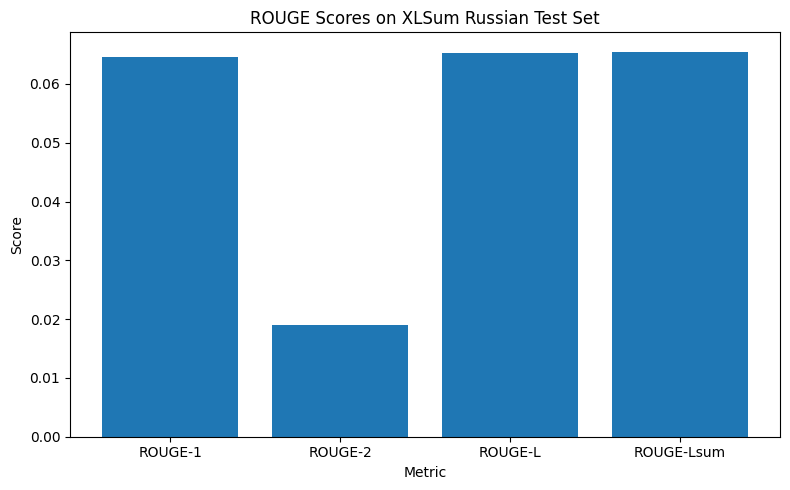

Saved: ./mbart50_xlsum_ru_singlelang_starter_visuals/report_plots/rouge_bar_chart_ru.png


,Metric,Score
0,ROUGE-1,0.0646
1,ROUGE-2,0.0190
2,ROUGE-L,0.0652
3,ROUGE-Lsum,0.0655


In [ ]:
rouge_plot_df = pd.DataFrame({
    "Metric": ["ROUGE-1", "ROUGE-2", "ROUGE-L", "ROUGE-Lsum"],
    "Score": [
        float(test_results.get("test_rouge1", 0)),
        float(test_results.get("test_rouge2", 0)),
        float(test_results.get("test_rougeL", 0)),
        float(test_results.get("test_rougeLsum", 0)),
    ]
})

plt.figure(figsize=(8, 5))
plt.bar(rouge_plot_df["Metric"], rouge_plot_df["Score"])
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title(f"ROUGE Scores on XLSum {LANGUAGE.title()} Test Set")
plt.tight_layout()
plot_path = os.path.join(PLOTS_DIR, f"rouge_bar_chart_{LANG_SHORT}.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)
rouge_plot_df

## 20. Training and evaluation loss curves

In [ ]:
log_history = trainer.state.log_history
logs_df = pd.DataFrame(log_history)
logs_df.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_rouge1,eval_rouge2,eval_rougeL,eval_rougeLsum,...,total_flos,train_loss,test_loss,test_rouge1,test_rouge2,test_rougeL,test_rougeLsum,test_runtime,test_samples_per_second,test_steps_per_second
0,2.9405,6.640976,0.000045,0.1,25,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.7673,5.859223,0.000040,0.2,50,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.7971,5.480063,0.000035,0.3,75,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.7500,6.033663,0.000030,0.4,100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.6618,6.025993,0.000025,0.5,125,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
train_loss_df = logs_df[logs_df["loss"].notna()].copy() if "loss" in logs_df.columns else pd.DataFrame()
eval_loss_df = logs_df[logs_df["eval_loss"].notna()].copy() if "eval_loss" in logs_df.columns else pd.DataFrame()

print("Train loss rows:", len(train_loss_df))
print("Eval loss rows:", len(eval_loss_df))

Train loss rows: 10
Eval loss rows: 1


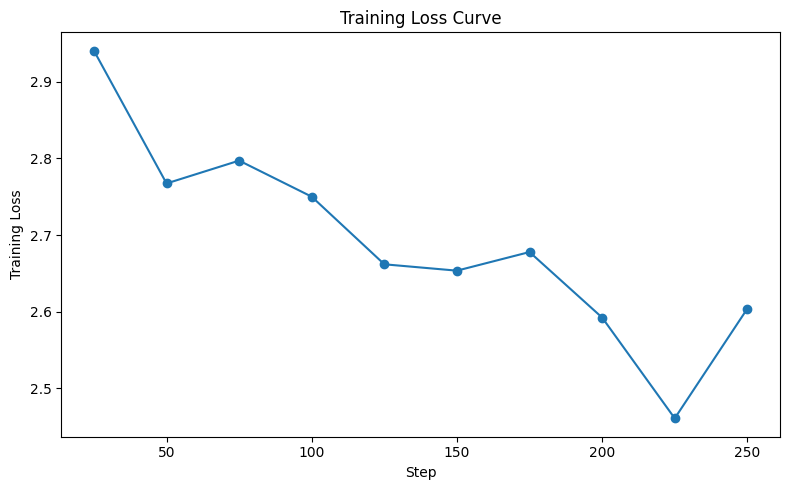

Saved: ./mbart50_xlsum_ru_singlelang_starter_visuals/report_plots/training_loss_curve_ru.png


In [ ]:
if not train_loss_df.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss_df["step"], train_loss_df["loss"], marker="o")
    plt.xlabel("Step")
    plt.ylabel("Training Loss")
    plt.title("Training Loss Curve")
    plt.tight_layout()
    plot_path = os.path.join(PLOTS_DIR, f"training_loss_curve_{LANG_SHORT}.png")
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", plot_path)
else:
    print("No training loss logs found.")

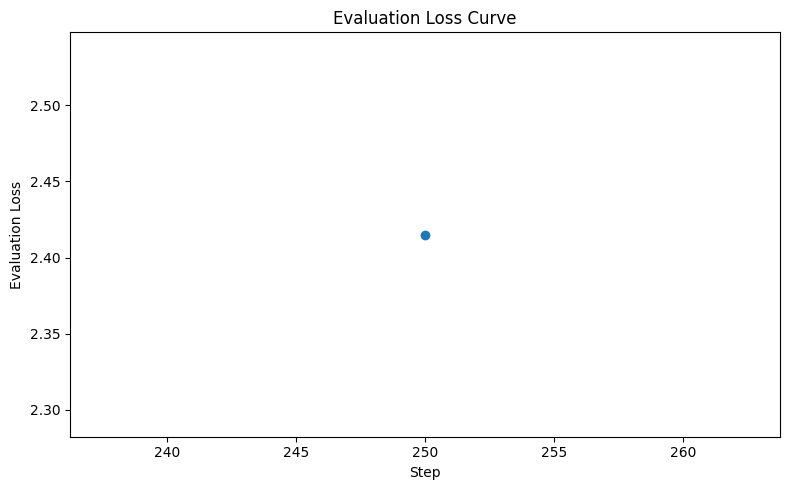

Saved: ./mbart50_xlsum_ru_singlelang_starter_visuals/report_plots/eval_loss_curve_ru.png


In [ ]:
if not eval_loss_df.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(eval_loss_df["step"], eval_loss_df["eval_loss"], marker="o")
    plt.xlabel("Step")
    plt.ylabel("Evaluation Loss")
    plt.title("Evaluation Loss Curve")
    plt.tight_layout()
    plot_path = os.path.join(PLOTS_DIR, f"eval_loss_curve_{LANG_SHORT}.png")
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", plot_path)
else:
    print("No evaluation loss logs found.")

## 21. Generate summaries for qualitative examples

In [ ]:
def generate_summary(text, max_new_tokens=64):
    device = model.device

    tokenizer.src_lang = MBART_LANG_CODES[LANGUAGE]
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_LEN
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            forced_bos_token_id=tokenizer.lang_code_to_id[MBART_LANG_CODES[LANGUAGE]]
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


In [ ]:
example_rows = []
num_examples = min(5, len(test_ds))

for i in range(num_examples):
    article = test_ds[i]["text"]
    gold_summary = test_ds[i]["summary"]
    pred_summary = generate_summary(article)

    example_rows.append({
        "Example": i + 1,
        "Article Snippet": article[:500].replace("\n", " "),
        "Gold Summary": gold_summary,
        "Predicted Summary": pred_summary
    })

examples_df = pd.DataFrame(example_rows)
examples_df

,Example,Article Snippet,Gold Summary,Predicted Summary
0,1,Энрике Каприлес потребовал расследования убийс...,Более 100 тысяч человек собрались в столице Ве...,"Президент Венесуэлы Энрике Каприлес заявил, чт..."
1,2,Президент США Дональд Трамп Исполнить свое нам...,Президент США Дональд Трамп еще в июне 2017 го...,В обзоре американских газет:
2,3,"Для того, чтобы все прошло удачно, потребуются...",Более 19 тысяч обитателей Лондонского зоопарка...,Взвесить и измерить взвешивание - это одна из ...
3,4,Владимир Путин уже трижды проходил процедуру и...,"Продолжавшаяся около четырех часов 15-я ""пряма...",Президент России Владимир Путин и его президен...
4,5,"Главные награды собрала лента ""За канделябрами...",22 сентября в Лос-Анджелесе состоялась церемон...,"Американская телеакадемия удостоилась премии ""..."


In [ ]:
examples_csv = os.path.join(TABLES_DIR, f"qualitative_examples_{LANG_SHORT}.csv")
examples_df.to_csv(examples_csv, index=False)
print("Saved:", examples_csv)

Saved: ./mbart50_xlsum_ru_singlelang_starter_visuals/report_tables/qualitative_examples_ru.csv


## 22. Save model and tokenizer

In [ ]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Saved model and tokenizer to: {OUTPUT_DIR}")

Saved model and tokenizer to: ./mbart50_xlsum_ru_singlelang_starter_visuals
